# 🏠 House Price Prediction 

### Dataset: *House Prices – Advanced Regression Techniques* (Ames Housing Dataset, Kaggle)


---
# 1. Project Introduction

## 📘 Concept

**House Price Prediction** means: *given the characteristics of a house — its size, location,
number of rooms, quality, age, and so on — can a computer estimate how much that house will
sell for?*

A human appraiser does this using experience. In Machine Learning we instead show a computer
**thousands of past house sales** (houses whose final price we already know). The computer
looks for patterns — for example, "bigger living area usually means a higher price" — and
learns a **mathematical rule** that maps house features to a price. We can then feed it a
**new** house it has never seen and it will output a predicted price.

## 🎯 Why is this a *Regression* problem?

Machine Learning tasks come in two big families:

- **Classification** → predict a **category / label** (e.g. *spam* vs *not spam*, *cat* vs *dog*).
- **Regression** → predict a **continuous number** (e.g. temperature, salary, **price**).

A house price is a number that can take (almost) any value — \$124,000, \$255,500, \$1,030,000.
There are no fixed "buckets". Because the thing we predict is a **continuous number**, this is
a **regression** problem. That single fact decides which models and which evaluation metrics
we are allowed to use later.

## 🌍 Real-world applications

The exact same workflow you learn here powers many products:

- **Real-estate websites** showing an automatic "estimated value" for every listing.
- **Banks** deciding how large a mortgage loan is safe to give against a property.
- **Insurance companies** pricing home insurance.
- **Property investors** spotting houses that are priced below their predicted value.
- **Governments** estimating property taxes fairly.

The technique generalises far beyond houses — predicting sales, demand, delivery time, or
energy usage are all the same kind of problem.

## 📦 Dataset overview

We use the famous **Ames Housing dataset** (collected in Ames, Iowa, USA). It is the standard
beginner dataset for regression because it is realistic and a little messy — just like real
data.

- About **1,460 houses** in the training file.
- **79 descriptive features** for each house (plus an `Id` column and the price).
- The thing we want to predict is the column **`SalePrice`** (the final selling price in US dollars).

The features describe almost everything about a house: lot size, neighbourhood, building type,
overall quality, year built, basement, garage, number of bathrooms, porch area, and much more.

## 🔄 The Machine Learning workflow

Almost every supervised ML project follows the same road map. This notebook walks through it
step by step:

1. **Understand the problem** (done above) — what are we predicting, and is it regression or classification?
2. **Load the data** into Python.
3. **Explore the data** (EDA) — look, plot, and understand before touching anything.
4. **Clean the data** — fix missing values, wrong types, and obvious errors.
5. **Feature engineering** — create smarter new columns from existing ones.
6. **Prepare the data for the model** — encode text categories, split into train/test, scale numbers.
7. **Train a model** — let the algorithm learn the patterns.
8. **Evaluate the model** — measure how good (or bad) the predictions are.
9. **Improve & iterate** — repeat steps 4–8 to do better (we touch on this at the end).

> **✅ Key Points**  
> • House price prediction = estimate a number → it is **regression**.  
> • The target column we predict is **`SalePrice`**.  
> • ML learns rules from **past examples** and applies them to **new** data.  
> • Every project follows roughly the same **workflow**; the rest of this notebook *is* that workflow.

> **⚠️ Common Mistakes**  
> • Jumping straight to building a model **before understanding the data** — this almost always backfires.  
> • Confusing regression with classification and then choosing the wrong metric.  
> • Treating the dataset as perfect. Real data is messy; cleaning it is most of the work.


---
# 2. Import Libraries

## 📘 Concept

A **library** is a collection of ready-made Python tools written by other people so we don't
have to build everything from scratch. Instead of writing hundreds of lines to, say, draw a
chart, we *import* a charting library and call one function.

We import every library **once, at the top** of the notebook. This is a universal convention:
anyone opening your notebook can immediately see what it depends on.

## ❓ Why is this important?

Each library is a specialist. Using the right tool for each job keeps our code short, fast,
and readable. Here is the toolkit for this project and what each part does:

| Library | Nickname | What we use it for |
|---|---|---|
| **pandas** | `pd` | Loading data and working with it as a table (rows & columns). The single most important data tool. |
| **numpy** | `np` | Fast maths on numbers and arrays (e.g. square roots, means). pandas is built on top of it. |
| **matplotlib** | `plt` | The base library for drawing charts. |
| **seaborn** | `sns` | Sits on top of matplotlib to make **prettier** statistical charts with less code. |
| **scikit-learn** | `sklearn` | The main Machine Learning library: models, splitting data, scaling, encoding, metrics. |

## 💻 Code


In [2]:
# --- Core data tools ---
import pandas as pd          # tables (DataFrames) for loading and handling data
import numpy as np           # fast numerical operations (e.g. np.sqrt, np.log)

# --- Visualisation tools ---
import matplotlib.pyplot as plt   # base plotting library
import seaborn as sns             # nicer statistical charts built on matplotlib

# --- Machine Learning tools (all from scikit-learn) ---
from sklearn.model_selection import train_test_split   # split data into train/test
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # scaling + encoding text
from sklearn.impute import SimpleImputer               # fill in missing values safely
from sklearn.compose import ColumnTransformer          # apply different steps to different columns
from sklearn.pipeline import Pipeline                  # chain steps together into one object
from sklearn.linear_model import LinearRegression      # our first ML model
from sklearn.metrics import (                          # tools to score the model
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# --- Notebook display settings (make outputs cleaner) ---
import warnings
warnings.filterwarnings("ignore")   # hide non-critical warnings so output stays readable

# Draw charts directly inside the notebook (instead of a separate window)
%matplotlib inline

# A clean, consistent look for every seaborn/matplotlib chart in this notebook
sns.set_theme(style="whitegrid")          # light grid background
plt.rcParams["figure.figsize"] = (8, 5)   # default chart size (width, height) in inches
plt.rcParams["axes.titlesize"] = 13       # default title font size

# Show more columns/width when printing tables, so nothing is hidden by "..."
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print(" All libraries imported successfully.")

 All libraries imported successfully.


---
# 3. Load the Dataset

## 📘 Concept

The data lives in **CSV files** (Comma-Separated Values — plain text where each line is a row
and commas separate the columns). We use pandas to read a CSV into a **DataFrame**: a table in
memory, with labelled rows and columns, that we can slice, filter, and analyse.

Kaggle gives us **three** files. Understanding why is important:

| File | What is inside | Has `SalePrice`? |
|---|---|---|
| **`train.csv`** | Past sales we **learn from**. Each house has all its features **and** the true `SalePrice`. | ✅ Yes |
| **`test.csv`** | Houses we must **predict**. Same features, **but the `SalePrice` is hidden**. | ❌ No |
| **`sample_submission.csv`** | A small template showing the **exact format** Kaggle expects your answers in (an `Id` column and a `SalePrice` column). | ✅ (dummy values) |

Why two separate files? Because the whole point of ML is to predict the **unseen**. Kaggle
keeps the real test prices secret so nobody can cheat by memorising them. You train on
`train.csv`, predict prices for `test.csv`, and Kaggle scores how close you were.

> In this notebook we focus on `train.csv` (the only file with answers) for learning and
> evaluation. Right at the end we show how to predict on `test.csv` and build a submission file.

## 💻 Code


In [3]:
# The folder that holds the CSV files. "." means "the current folder"
# (the same folder as this notebook). Change it if your files are elsewhere.
import os
DATA_DIR = "."

# Read each CSV file into its own DataFrame (a table in memory)
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))                 # houses WITH known prices
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))                   # houses WITHOUT prices
sample_submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))  # answer template

print("Files loaded successfully!")
print("train rows, columns       :", train.shape)
print("test  rows, columns       :", test.shape)
print("submission rows, columns  :", sample_submission.shape)

Files loaded successfully!
train rows, columns       : (1460, 81)
test  rows, columns       : (1459, 80)
submission rows, columns  : (1459, 2)


### Peeking at the data: `head()` and `tail()`

**`head(n)`** shows the **first** `n` rows; **`tail(n)`** shows the **last** `n` rows. We use
them constantly to *eyeball* the data and sanity-check that it loaded correctly.


In [3]:
# Show the first 5 rows. This is the #1 command you run after loading any dataset.
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Show the last 5 rows — confirms the file wasn't cut off and the end looks sensible.
train.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


### The column names and their data types: `columns` and `info()`

**`.columns`** lists every column name. **`.info()`** is a quick health report: for each
column it shows how many values are **non-null** (present) and the **data type**
(`int64`/`float64` = numbers, `object` = text).


In [5]:
# List all column names so we know what features we have to work with
print("All", len(train.columns), "columns:\n")
print(list(train.columns))

All 81 columns:

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'Po

In [6]:
# A compact technical summary: data type + how many non-missing values per column
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

**🔎 Output Explanation.** Read `info()` like this:

- The **Dtype** column tells you the type. `object` almost always means **text** (a category
  like `"RL"` or `"Gd"`). `int64`/`float64` mean **numbers**.
- The **Non-Null Count** tells you how many rows actually have a value. If a column says
  `1201 non-null` out of 1460, then `1460 - 1201 = 259` values are **missing**. This is our
  first hint of the cleaning work ahead.

Knowing each column's type matters because **numbers and text are handled completely
differently** by ML models (text must be converted to numbers first — Section 7).


### Statistical summary of the numbers: `describe()`

**`.describe()`** computes summary statistics for every **numeric** column at once: the count,
mean (average), standard deviation (spread), minimum, the 25th/50th/75th **percentiles**, and
the maximum.


In [7]:
# Summary statistics for all numeric columns. .T transposes it (columns become rows)
# so it is easier to scroll and read down the page.
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


**🔎 Output Explanation.** A few things to look for:

- **`mean` vs `50%` (the median).** If they are far apart for a column, that column is
  **skewed** (lopsided). For `SalePrice` the mean (~\$180,900) is noticeably above the median
  (~\$163,000) → prices are skewed toward a few expensive houses.
- **`min` and `max`.** These reveal the range and possible **outliers**. For example a huge
  `max` `LotArea` far above the `75%` value hints at a few very large lots.
- **`std` (standard deviation).** Roughly, how spread out the values are around the mean. Big
  `std` = values vary a lot.

Statistics on **text** columns are not shown here because averages don't make sense for words;
we explore those separately in the EDA section.

> **✅ Key Points**  
> • `read_csv` turns a CSV file into a pandas **DataFrame** (a table).  
> • `train` has the answer (`SalePrice`); `test` does not.  
> • `head`/`tail` eyeball the data; `info` shows types & missing counts; `describe` summarises the numbers.  
> • A gap between **mean** and **median** signals **skew**.


---
# 4. Exploratory Data Analysis (EDA)

## 📘 Concept

**EDA** means *getting to know your data before modelling*, mostly through **summaries and
charts**. We are detectives here: looking for patterns, surprises, errors, and relationships.
A picture really is worth a thousand numbers — a single scatter plot can reveal something no
table will.

## ❓ Why is this important?

You cannot fix or model what you don't understand. Good EDA tells us:

- which features are **strongly related** to price (these will matter most to the model),
- where the **missing values** and **outliers** are (so we can clean them),
- whether the data has any **errors** or surprises.

> **The golden rule: explore *before* you clean or model.** Skipping EDA is the #1 reason
> beginner models silently underperform.

We will look, in order, at: (1) the target, (2) missing values, (3) duplicates,
(4) numeric vs categorical features, (5) distributions, (6) relationships with `SalePrice`,
(7) correlations, and (8) outliers.


## 4.1 Understand the target: `SalePrice`

Before anything else, study the thing you are predicting. We plot its **distribution** (the
shape of how values are spread) with a **histogram** — bars showing how many houses fall in
each price range. The smooth curve (KDE) is just a smoothed version of those bars.


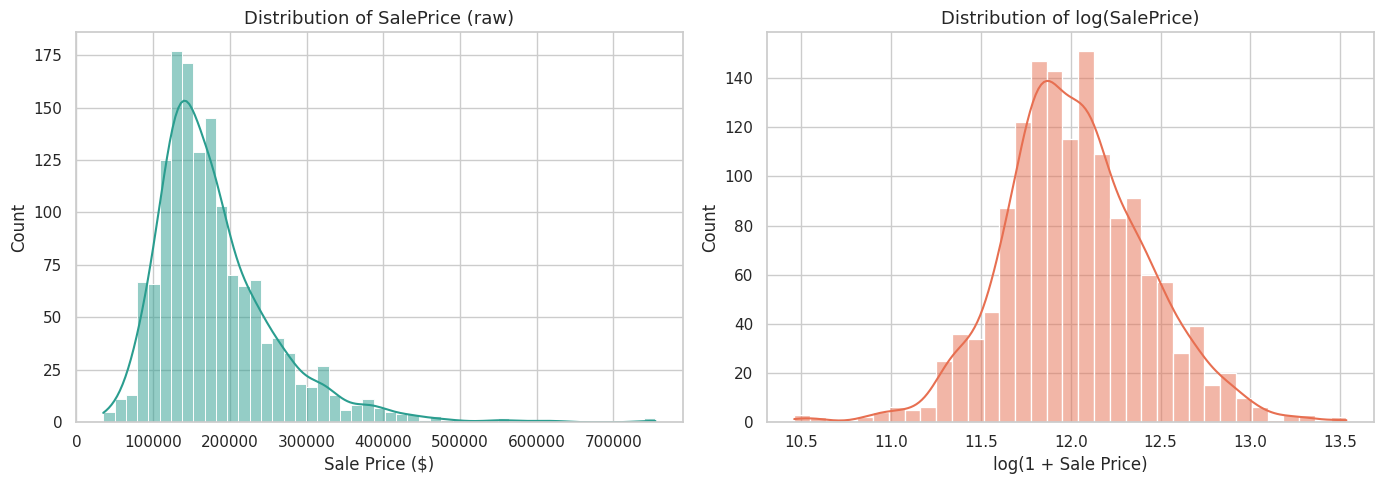

Skewness of SalePrice      : 1.883
Skewness of log(SalePrice) : 0.121


In [8]:
# Two charts side by side to study the target's shape
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: histogram of SalePrice (raw dollars)
sns.histplot(train["SalePrice"], kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Distribution of SalePrice (raw)")
axes[0].set_xlabel("Sale Price ($)")

# RIGHT: histogram of the LOG of SalePrice.
# np.log1p(x) computes log(1 + x); taking a log squashes large values and
# pulls a right-skewed distribution closer to a symmetric "bell" shape.
sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1], color="#e76f51")
axes[1].set_title("Distribution of log(SalePrice)")
axes[1].set_xlabel("log(1 + Sale Price)")

plt.tight_layout()
plt.show()

# A single number for skewness: 0 = symmetric, >0 = tail on the right (high values)
print("Skewness of SalePrice      :", round(train["SalePrice"].skew(), 3))
print("Skewness of log(SalePrice) :", round(np.log1p(train["SalePrice"]).skew(), 3))

**🔎 Output Explanation.** The **left** chart is clearly **right-skewed**: most houses
are moderately priced, with a long thin tail of a few very expensive homes pulling the average
up. The **right** chart shows that after a `log` transform the shape becomes much more
symmetric (a nice "bell"). The skewness number drops from around **1.9** (very skewed) to
near **0** (symmetric).

Why do we care? **Linear models work best when the target is roughly symmetric**, because a
few extreme prices can otherwise dominate the learning. We keep the raw price for now (to keep
the first model simple), but remember this — at the end we show that predicting `log(SalePrice)`
gives a better score. This is your first taste of how EDA directly improves modelling.


## 4.2 Missing values

A **missing value** (`NaN`) is a blank cell — information that was never recorded. Models
cannot do maths on a blank, so every missing value must eventually be handled. First we simply
**measure** how many there are and where.


In [5]:
# Count missing values per column, keep only columns that HAVE missing values,
# and sort from worst to least.
missing_counts = train.isnull().sum()                 # .isnull() -> True/False; .sum() counts the Trues
missing_counts = missing_counts[missing_counts > 0]    # keep only columns with at least one missing
missing_counts = missing_counts.sort_values(ascending=False)

# Build a tidy summary table with the percentage missing too
missing_table = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": (missing_counts / len(train) * 100).round(1),
})
print("Columns with missing values:", len(missing_table))
missing_table

Columns with missing values: 19


,Missing Count,Missing %
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


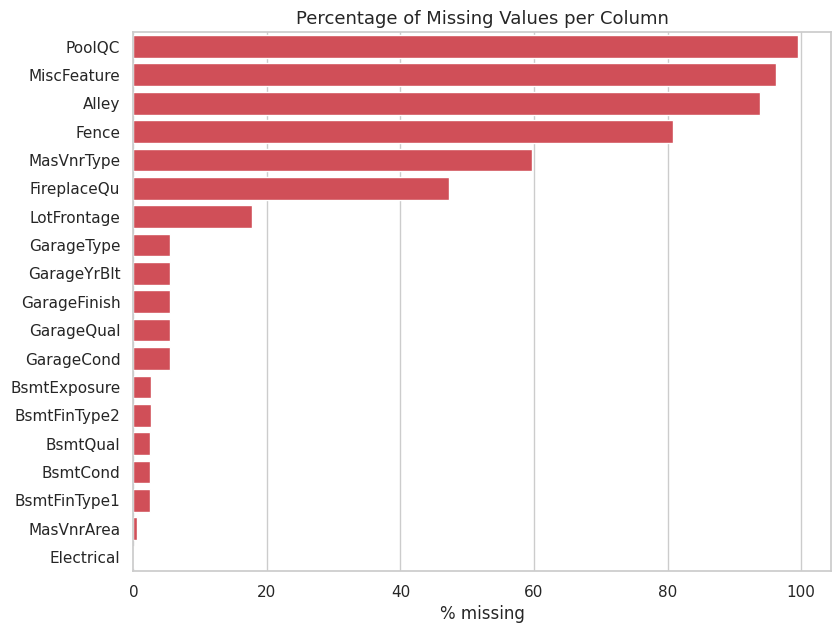

In [10]:
# Visualise the worst offenders as a horizontal bar chart (easier to read names)
plt.figure(figsize=(9, 7))
sns.barplot(x=missing_table["Missing %"], y=missing_table.index, color="#e63946")
plt.title("Percentage of Missing Values per Column")
plt.xlabel("% missing")
plt.ylabel("")
plt.show()

**🔎 Output Explanation.** A handful of columns are *mostly* empty — `PoolQC` (~99.5%),
`MiscFeature` (~96%), `Alley` (~94%), `Fence` (~81%). At first glance you might delete them.
**But here is the crucial insight, and a very common trap:** in this dataset a missing value
often does **not** mean "unknown" — it means "**this house does not have that thing**". A blank
`PoolQC` means *no pool*; a blank `GarageType` means *no garage*. The official data description
confirms this. So instead of deleting these columns, in cleaning we will fill those blanks with
the label `"None"`. Only a few columns (like `LotFrontage`) are *genuinely* unknown numbers.
We will treat the two kinds differently in Section 5.


## 4.3 Duplicate rows

A **duplicate** is an identical row that appears more than once. Duplicates can bias a model
(it "sees" the same house twice) so we check for them.


In [11]:
# .duplicated() flags rows that are exact copies of an earlier row; .sum() counts them
print("Number of fully duplicated rows :", train.duplicated().sum())

# The Id column should be unique (one number per house) — verify there are no repeats
print("Number of duplicated Id values  :", train["Id"].duplicated().sum())

Number of fully duplicated rows : 0
Number of duplicated Id values  : 0


**🔎 Output Explanation.** Both numbers are **0**. Good — every row is a unique house and
every `Id` is unique, so we have no duplicates to remove. (Always check anyway; never assume.)


## 4.4 Numeric vs categorical features

We split columns into two groups because they need different handling:

- **Numeric** features hold numbers we can do maths on (`GrLivArea`, `YearBuilt`).
- **Categorical** features hold text labels / categories (`Neighborhood`, `MSZoning`).


In [6]:
# Select columns by their data type.
# include="number" grabs all integer/float columns; include="object" grabs text columns.
numeric_features = train.select_dtypes(include="number").columns.tolist()
categorical_features = train.select_dtypes(include="object").columns.tolist()

print("Number of NUMERIC columns     :", len(numeric_features))
print("Number of CATEGORICAL columns :", len(categorical_features))
print()
print("First few numeric     :", numeric_features[:8])
print("First few categorical :", categorical_features[:8])

Number of NUMERIC columns     : 38
Number of CATEGORICAL columns : 43

First few numeric     : ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd']
First few categorical : ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope']


**🔎 Output Explanation.** We have roughly **38 numeric** and **43 categorical** columns
(the 38 numeric includes `Id` and `SalePrice`, which are *not* normal predictors — `Id` is just
a label and `SalePrice` is the target). This split guides everything later: numeric columns get
**scaled**, categorical columns get **encoded** into numbers.


## 4.5 Distributions of a few numeric features (histograms)

A **histogram** shows the shape of one numeric column — where values cluster and whether the
column is skewed. We look at a few important ones.


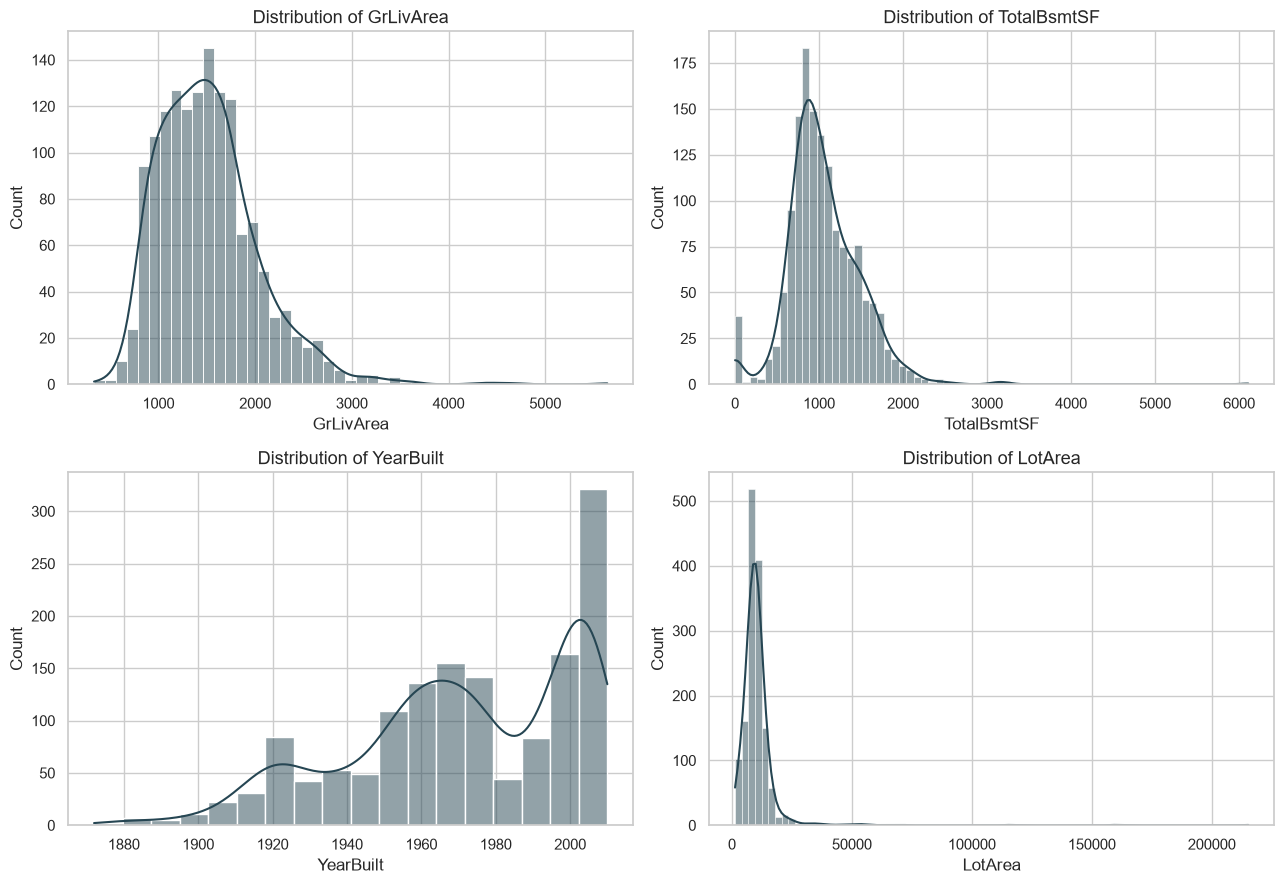

In [7]:
# Pick a few meaningful numeric features and draw a histogram for each
cols_to_plot = ["GrLivArea", "TotalBsmtSF", "YearBuilt", "LotArea"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()   # flatten the 2x2 grid into a simple list of 4 axes

for i, col in enumerate(cols_to_plot):
    sns.histplot(train[col], kde=True, ax=axes[i], color="#264653")
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

**🔎 Output Explanation.**
- **`GrLivArea`** (above-ground living area) is right-skewed — most homes are small/medium with
  a few very large ones.
- **`TotalBsmtSF`** has a spike at 0 (houses with **no basement**) plus a spread for the rest.
- **`YearBuilt`** shows construction has increased over time, with a surge of newer homes.
- **`LotArea`** is heavily right-skewed with a few enormous lots (potential outliers).

Spotting skew and "spikes at zero" early tells us which features may need transforming and
reminds us that 0 often means "feature absent".


## 4.6 A categorical feature: count plot

For categorical data, a **count plot** is the equivalent of a histogram: a bar for each
category showing how many houses fall into it. We look at `OverallQual` (overall material &
finish quality, rated 1–10) — it behaves like a category and is one of the strongest signals
for price.


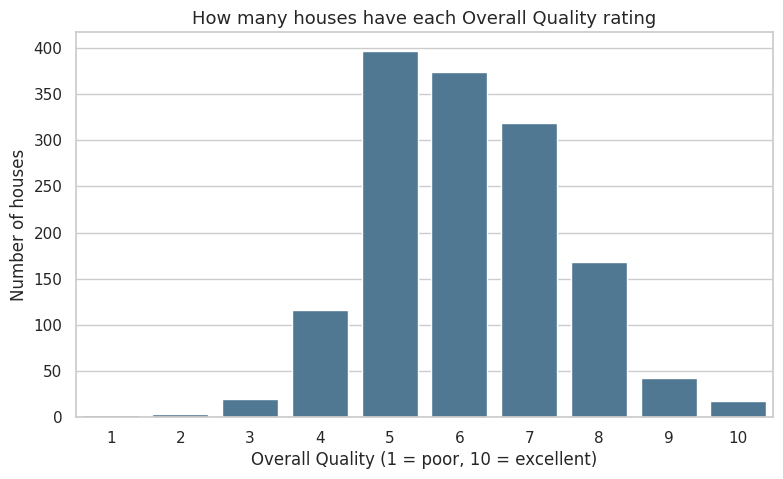

In [14]:
plt.figure(figsize=(9, 5))
# Count how many houses have each OverallQual rating (1 = very poor ... 10 = excellent)
sns.countplot(data=train, x="OverallQual", color="#457b9d")
plt.title("How many houses have each Overall Quality rating")
plt.xlabel("Overall Quality (1 = poor, 10 = excellent)")
plt.ylabel("Number of houses")
plt.show()

**🔎 Output Explanation.** Most houses cluster around quality **5–7** (average to good),
with very few at the extremes. Knowing the typical range is useful — and because higher quality
strongly pushes price up (we confirm this next), `OverallQual` will likely be one of our most
important features.


## 4.7 Relationship with `SalePrice` — scatter plots

Now the heart of EDA: **how does each feature relate to the price?** For two numeric columns we
use a **scatter plot** — each dot is one house, positioned by the feature (x-axis) and the price
(y-axis). An upward cloud of dots means "as the feature goes up, price tends to go up".


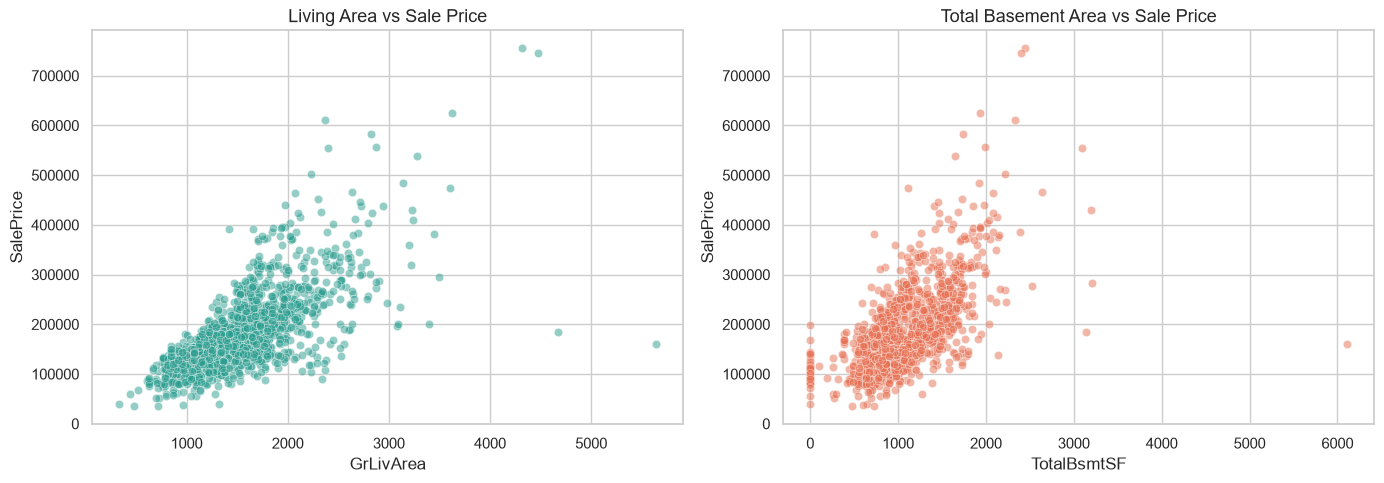

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Living area vs price — expected to rise together
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", ax=axes[0], alpha=0.5, color="#2a9d8f")
axes[0].set_title("Living Area vs Sale Price")

# Basement area vs price
sns.scatterplot(data=train, x="TotalBsmtSF", y="SalePrice", ax=axes[1], alpha=0.5, color="#e76f51")
axes[1].set_title("Total Basement Area vs Sale Price")

plt.tight_layout()
plt.show()

**🔎 Output Explanation.** Both clouds slope **upward** — bigger living area and bigger
basement clearly mean higher prices. This is exactly the kind of pattern a regression model
will capture. Look at the bottom-right of the **living area** plot: there are **two houses with
a very large area but a surprisingly low price**. Those are **outliers** (perhaps a strange sale)
and we will revisit them in the outlier section.


## 4.8 Relationship with `SalePrice` — box plots for categories

To see how a **categorical** feature relates to price, we use a **box plot**: one box per
category summarising the spread of prices in that category. The line in each box is the median;
the box covers the middle 50% of prices.


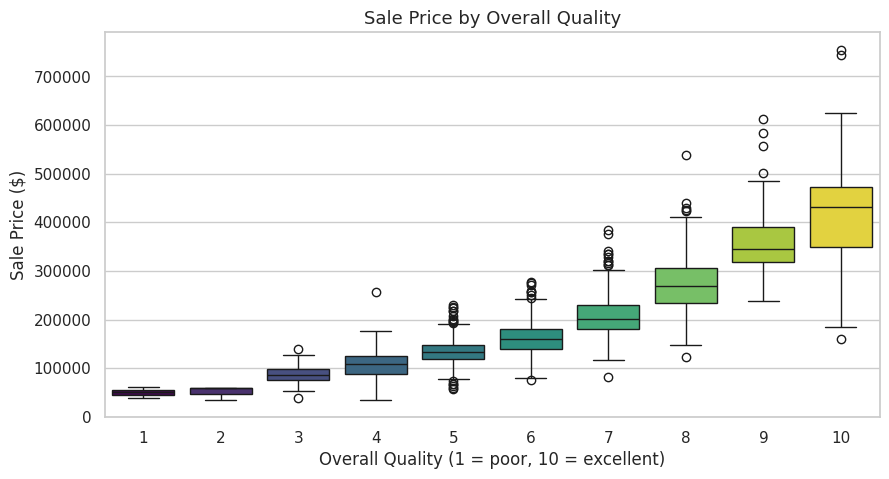

In [16]:
# Price by Overall Quality: do better-quality houses sell for more?
plt.figure(figsize=(10, 5))
sns.boxplot(data=train, x="OverallQual", y="SalePrice", palette="viridis", hue="OverallQual", legend=False)
plt.title("Sale Price by Overall Quality")
plt.xlabel("Overall Quality (1 = poor, 10 = excellent)")
plt.ylabel("Sale Price ($)")
plt.show()

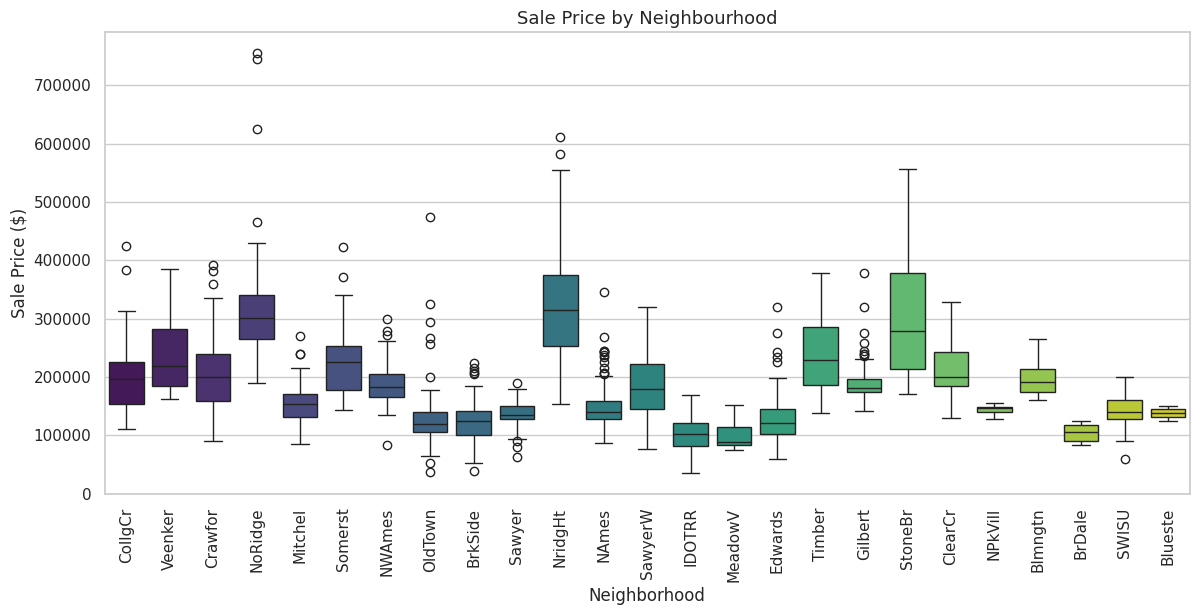

In [17]:
# Price by Neighborhood: location, location, location.
# We rotate the x labels so the neighbourhood names don't overlap.
plt.figure(figsize=(14, 6))
sns.boxplot(data=train, x="Neighborhood", y="SalePrice", palette="viridis", hue="Neighborhood", legend=False)
plt.title("Sale Price by Neighbourhood")
plt.xticks(rotation=90)   # turn labels vertical so they fit
plt.ylabel("Sale Price ($)")
plt.show()

**🔎 Output Explanation.** The quality box plot shows a **clear staircase**: each step up
in quality lifts the whole price range. The neighbourhood plot shows **location matters a lot** —
some areas (e.g. *NridgHt*, *NoRidge*, *StoneBr*) command far higher prices than others. These
are strong, intuitive signals that confirm the dataset makes real-world sense.


## 4.9 Correlation matrix & heatmap

**Correlation** measures how strongly two numeric columns move together, as a number between
**-1 and +1**:

- **+1** → perfect positive (one goes up, the other goes up).
- **0** → no linear relationship.
- **-1** → perfect negative (one goes up, the other goes down).

A **heatmap** colours these numbers so patterns jump out. We especially care about each
feature's correlation **with `SalePrice`**.


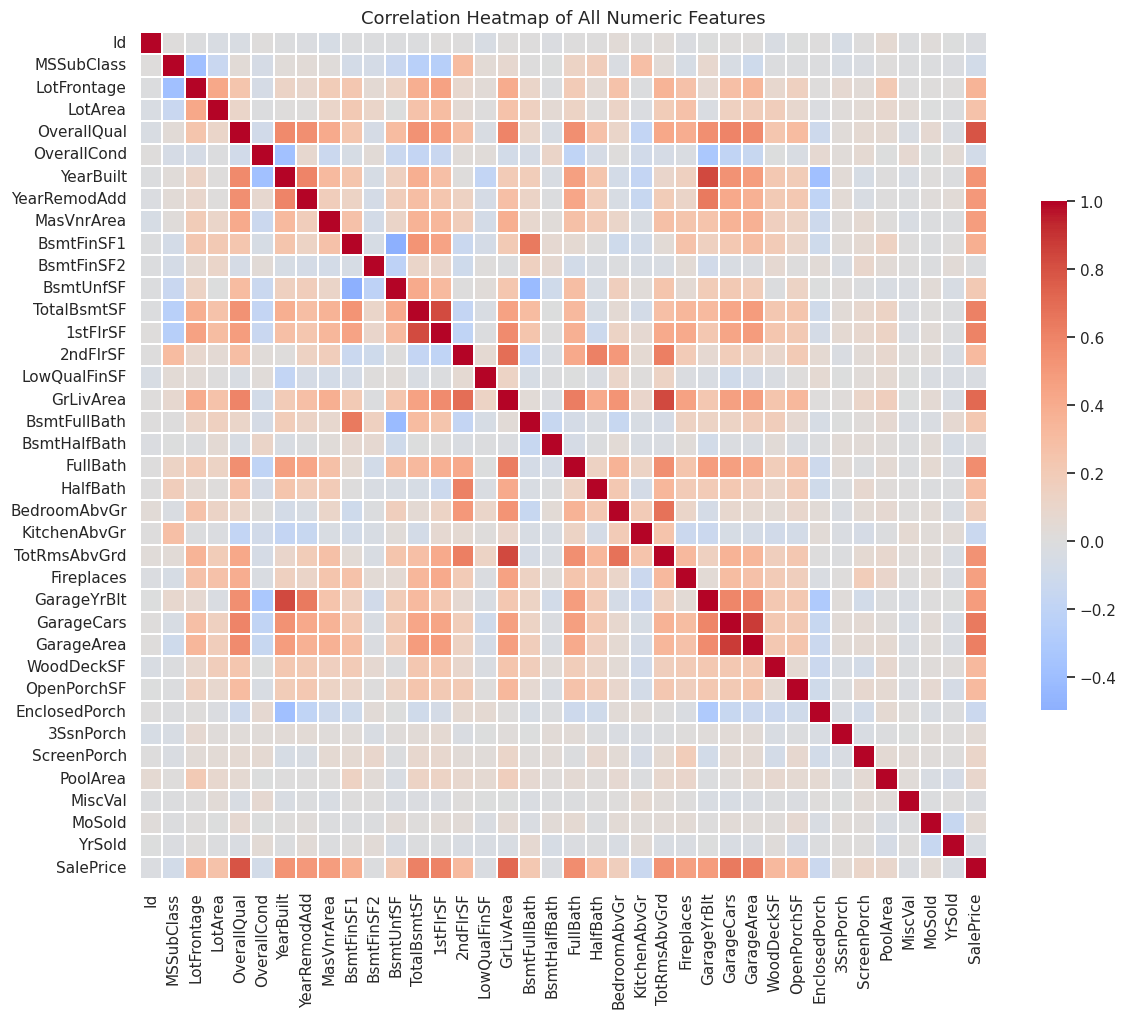

In [18]:
# Correlation only makes sense for numbers, so select numeric columns first.
corr = train.select_dtypes(include="number").corr()

# Full heatmap of every numeric pair. With ~38 features the numbers would be unreadable,
# so we show colour only (no annotations) just to see the overall pattern.
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            linewidths=0.3, cbar_kws={"shrink": 0.6})
plt.title("Correlation Heatmap of All Numeric Features")
plt.show()

In [19]:
# More useful for us: the 12 features most correlated with SalePrice.
top_corr = corr["SalePrice"].sort_values(ascending=False)   # sort high -> low
print("Top features positively correlated with SalePrice:\n")
print(top_corr.head(13).round(3))   # 13 because the first one is SalePrice with itself (=1.0)

Top features positively correlated with SalePrice:

SalePrice       1.000
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
GarageYrBlt     0.486
MasVnrArea      0.477
Name: SalePrice, dtype: float64


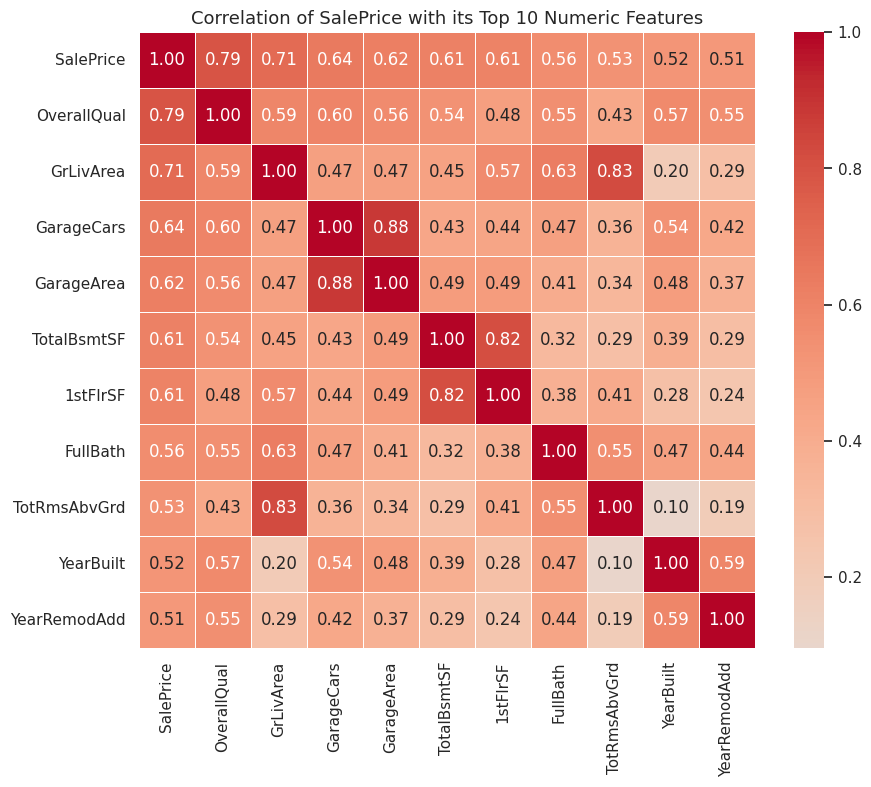

In [20]:
# A focused, readable heatmap: SalePrice + its 10 strongest numeric partners,
# this time WITH the correlation numbers printed in each cell.
top_features = top_corr.head(11).index               # SalePrice + top 10 others
plt.figure(figsize=(10, 8))
sns.heatmap(train[top_features].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation of SalePrice with its Top 10 Numeric Features")
plt.show()

**🔎 Output Explanation.** The strongest drivers of price (correlation in brackets) are:

- **`OverallQual`** (~0.79) — overall quality, the single best numeric predictor.
- **`GrLivArea`** (~0.71) — above-ground living area.
- **`GarageCars`** / **`GarageArea`** (~0.64 / ~0.62) — garage capacity/size.
- **`TotalBsmtSF`** / **`1stFlrSF`** (~0.61) — basement and first-floor area.

Notice also that some features are strongly correlated **with each other** (e.g. `GarageCars`
and `GarageArea`, or `TotalBsmtSF` and `1stFlrSF`) — they measure almost the same thing. This
is called **multicollinearity**; it doesn't hurt our predictions much but it can make a linear
model's individual coefficients harder to interpret.


## 4.10 Outlier detection

An **outlier** is a data point that lies far away from the rest. Outliers can drag a linear
model off course, so we hunt for them. A **box plot** marks them as dots beyond the
"whiskers". We already spotted two suspicious houses in the living-area scatter — let's confirm.


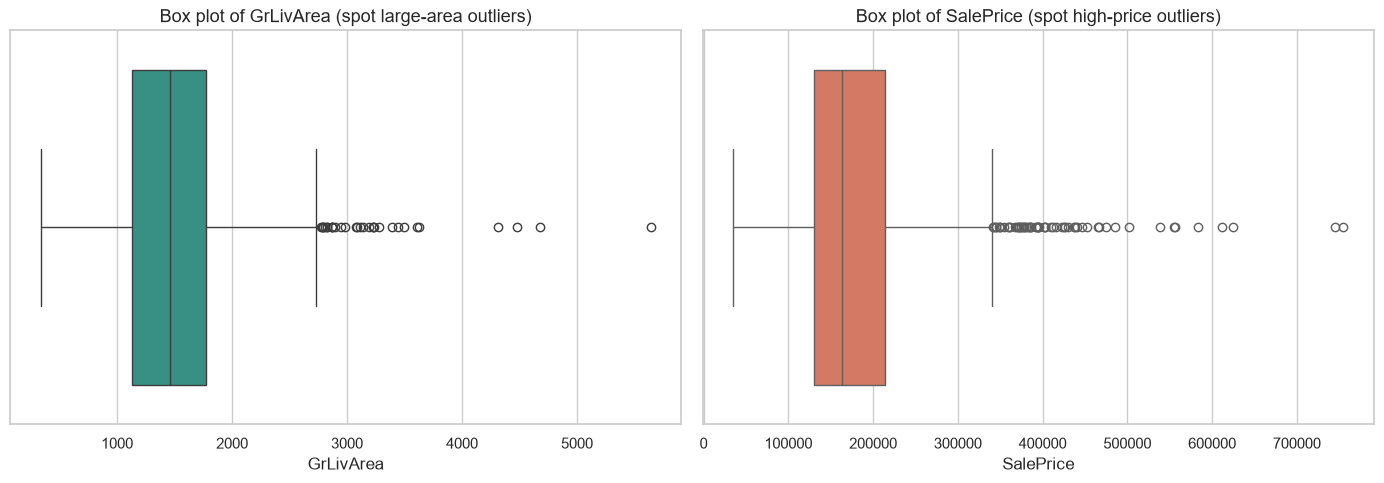

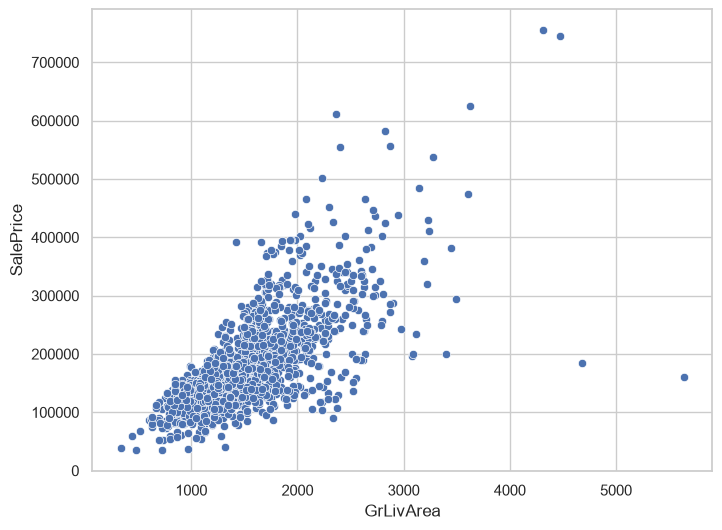

Suspicious houses (huge area but low price):
        Id  GrLivArea  SalePrice  OverallQual
523    524       4676     184750           10
1298  1299       5642     160000           10


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of GrLivArea — dots far to the right are unusually large homes
sns.boxplot(x=train["GrLivArea"], ax=axes[0], color="#2a9d8f")
axes[0].set_title("Box plot of GrLivArea (spot large-area outliers)")

# Box plot of SalePrice — dots far to the right are unusually expensive homes
sns.boxplot(x=train["SalePrice"], ax=axes[1], color="#e76f51")
axes[1].set_title("Box plot of SalePrice (spot high-price outliers)")

plt.tight_layout()
plt.show()

# The two classic Ames outliers: very large living area BUT low price.
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice"
)
plt.show()


weird = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 200000)]
print("Suspicious houses (huge area but low price):")
print(weird[["Id", "GrLivArea", "SalePrice", "OverallQual"]])

**🔎 Output Explanation.** The box plots confirm a tail of large-area and high-price
outliers. The printed table isolates **two famous houses** in this dataset: they have a *huge*
living area (>4000 sq ft) yet sold *cheaply* (<\$200,000) — likely unusual/partial sales. Many
Kaggle competitors remove these two rows because they confuse linear models. We will **keep all
data in this beginner notebook** for simplicity, but we now *know* they exist — and noting them
is the whole point of outlier detection.

> **✅ Key Points**  
> • EDA = **understand before you model**: summaries + charts.  
> • `SalePrice` is **right-skewed**; a `log` transform makes it symmetric (useful later).  
> • Missing values here often mean **"feature absent"**, not "unknown".  
> • `OverallQual`, `GrLivArea`, garage and basement sizes are the **strongest** price drivers.  
> • Box plots and scatter plots reveal **outliers** (two odd large-but-cheap houses).

> **⚠️ Common Mistakes**  
> • Deleting "mostly empty" columns without checking the data description (their blanks mean *None*).  
> • Reading correlation as **causation** — it only measures linear association.  
> • Ignoring outliers, then being puzzled when the model misbehaves.  
> • Only looking at numbers and never plotting — charts reveal what tables hide.


---
# 5. Data Cleaning

## 📘 Concept

**Data cleaning** means fixing problems in the raw data so a model can actually use it. The
three big jobs are: handling **missing values**, fixing **wrong data types**, and removing
**columns that don't help**.

## ❓ Why is this important?

> **"Garbage in, garbage out."** A model is only as good as the data you feed it.

Most ML models *cannot run at all* if there are blank cells, and they will *misunderstand* a
column whose type is wrong. Cleaning is unglamorous but it is where most of the real work — and
most of the improvement — happens.

We always clean a **copy** of the data, never the original, so we can start over if needed.


In [9]:
# Work on a COPY so the original `train` stays untouched (good safety habit)
df = train.copy()
print("Working copy created with shape:", df.shape)

Working copy created with shape: (1460, 81)


## 5.1 Drop columns that don't help

The **`Id`** column is just a row number (1, 2, 3, ...). It has no relationship to price — it
is only a label. Feeding it to the model would add noise, so we drop it.


In [10]:
# Remove the Id column. axis=1 means "drop a column" (axis=0 would mean a row).
df = df.drop(columns=["Id"])
print("After dropping Id, shape:", df.shape)

After dropping Id, shape: (1460, 80)


## 5.2 Handle missing values — *the smart way*

This is the most important cleaning step, and the place beginners most often go wrong. From EDA
we learned there are really **three different kinds** of missing value here, and each needs a
different fix:

1. **"Missing" actually means "feature absent."** For columns like `PoolQC`, `Alley`,
   `GarageType`, `BsmtQual`, a blank means the house simply has *no pool / no alley / no garage
   / no basement*. The correct fix is to fill these with the text label **`"None"`** — that is
   real information, not a guess.
2. **A missing number that naturally means zero.** `MasVnrArea` (masonry veneer area) is blank
   when there is no veneer, so the true value is **0**.
3. **A genuinely unknown value.** `LotFrontage` (street frontage) and a single blank in
   `Electrical` are truly unrecorded. These should be filled with a **statistic** (the median
   for numbers, the most frequent value for text). **Important:** we will *not* do this here —
   we deliberately leave it to the **pipeline** in Section 9, so the statistic is computed using
   *training data only*. (Computing it now, before the train/test split, would leak information
   from the test set — explained fully in Section 9.)


In [11]:
# --- Kind 1: blanks that truly mean "this feature is absent" -> fill with the label "None" ---
# (Confirmed by the dataset's official data_description.txt.)
none_means_absent = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "MasVnrType",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
]
for col in none_means_absent:
    df[col] = df[col].fillna("None")   # replace NaN with the string "None"

# --- Kind 2: a missing area that means zero ---
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)   # no veneer -> 0 square feet

# --- Kind 3 (LotFrontage, GarageYrBlt, Electrical): left for the pipeline on purpose ---

# Check what missing values remain after our domain-based fixes
remaining = df.isnull().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
print("Missing values remaining (to be handled inside the pipeline):")
print(remaining)

Missing values remaining (to be handled inside the pipeline):
LotFrontage    259
GarageYrBlt     81
Electrical       1
dtype: int64


**🔎 Output Explanation.** After our domain-based fixes, only a few columns still have
blanks — typically **`LotFrontage`**, **`GarageYrBlt`**, and **`Electrical`**. That is
**intentional**. These are the genuinely-unknown values, and we will fill them *inside the
pipeline* (Section 9) using statistics learned from the training data only. This keeps our
process honest and leak-free.


## 5.3 Fix an incorrect data type

`MSSubClass` looks like a number (20, 60, 120, ...) but those numbers are really **codes for
building types** (20 = "1-storey 1946 & newer", 60 = "2-storey 1946 & newer", and so on). The
code 120 is **not** "six times more" than 20 — they are just labels. If we leave it as a number,
the model will wrongly assume an order and magnitude. The fix: convert it to **text** so it is
treated as a category.


In [12]:
# Convert MSSubClass from a number to text so it becomes a true category, not a magnitude.
df["MSSubClass"] = df["MSSubClass"].astype(str)
print("MSSubClass dtype is now:", df["MSSubClass"].dtype, "(object = text/category) ✅")

MSSubClass dtype is now: str (object = text/category) ✅


## 5.4 Remove the two outliers we found in EDA

Back in the EDA section we spotted **two famous houses**: they have a *huge* above-ground living
area (`GrLivArea > 4000` sq ft) yet sold for a *surprisingly low* price (under \$200,000). These
are genuine oddities (likely unusual sales), and because a straight line tries to please **every**
point, two extreme cases like these can **tilt the whole line** and hurt predictions for normal
homes. Now that we are cleaning, we act on what EDA revealed and drop just these two rows.

> ⚠️ Be conservative when deleting rows. We remove only these **two clearly justified** points —
> not every large or expensive house. Deleting data should always be the rare, well-reasoned
> exception, never a habit.


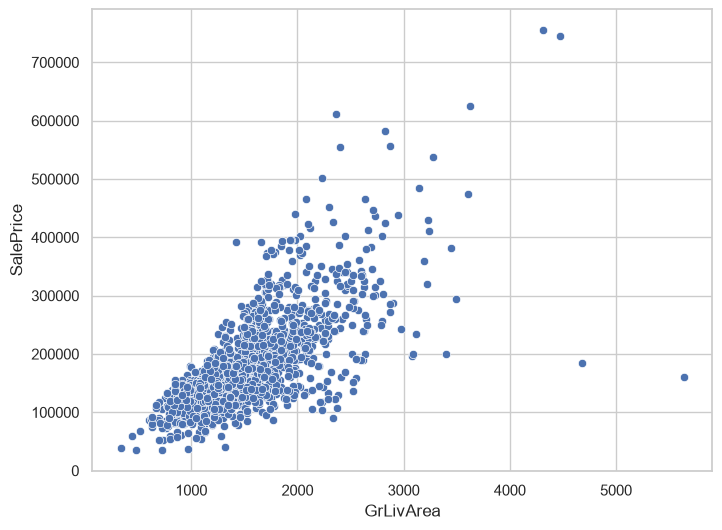

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice"
)
plt.show()

In [14]:
# Remember the size before, so we can prove exactly how many rows we removed.
rows_before = df.shape[0]

# Keep every row EXCEPT the two extreme "big house, low price" outliers from EDA.
df = df[~((df["GrLivArea"] > 4000) & (df["SalePrice"] < 200000))].reset_index(drop=True)

# ~ means NOT

print(f"Rows before: {rows_before}")
print(f"Rows after : {df.shape[0]}")
print(f"Removed     : {rows_before - df.shape[0]} outlier row(s)")

Rows before: 1460
Rows after : 1458
Removed     : 2 outlier row(s)


**🔎 Output Explanation.** Exactly **two** rows were removed, leaving the dataset almost
untouched (we kept well over 99.8% of it). This small, deliberate edit removes two points that
would otherwise distort our linear model the most. We reset the index so the row numbers stay
tidy and continuous afterwards.


> **✅ Key Points**  
> • Always clean a **copy** of your data.  
> • Drop pure-label columns like `Id`.  
> • Not all missing values are equal — here many mean **"absent" → fill with `"None"`** or **0**, while a few are **truly unknown → fill with a statistic inside the pipeline**.  
> • Convert code-like numbers (`MSSubClass`) to **text** so they aren't misread as magnitudes.  
> • Remove only **clearly justified** outliers (here, just two) — sparingly and with a reason.

> **⚠️ Common Mistakes**  
> • Blindly dropping every row or column that has a missing value — you can throw away most of your data.  
> • Filling *all* blanks with `0` or the mean without thinking about what the blank means.  
> • Filling unknown values using the **whole** dataset's statistics *before* splitting → **data leakage** (Section 9).  
> • Leaving code-like numbers as numbers, so the model invents a fake ordering.  
> • Deleting outliers **aggressively** — removing too many real points throws away genuine information and can make the model worse.


---
# 6. Feature Engineering

## 📘 Concept

**Feature engineering** means **creating new, more useful columns** out of the ones we already
have. We use our human, real-world knowledge to hand the model better ingredients.

## ❓ Why is this important?

A model can only find patterns in the columns you give it. Often a *combination* of columns is
far more meaningful than any single one. For example, buyers care about the **total** living
space of a house — but the dataset splits that across basement, 1st floor, and 2nd floor. By
adding them into one `TotalSF` column, we hand the model the concept it actually needs.

> Great features often help **more** than a fancier model. This step is where domain knowledge
> pays off.

We will create:

| New feature | Built from | Why it helps |
|---|---|---|
| `TotalSF` | basement + 1st floor + 2nd floor area | total usable space — what buyers really pay for |
| `TotalBath` | full + half + basement baths (halves count as 0.5) | one clean "how many bathrooms" number |
| `HouseAge` | `YrSold − YearBuilt` | age at sale; newer usually costs more |
| `RemodAge` | `YrSold − YearRemodAdd` | years since last remodel; recent updates add value |
| `TotalPorchSF` | all porch/deck areas added up | total outdoor space |
| `HasPool`, `HasGarage`, `HasFireplace`, `Has2ndFloor` | "is the area > 0?" | simple yes/no (1/0) flags for desirable features |

## 💻 Code


In [27]:
def add_features(data):
    """Return a copy of `data` with extra engineered columns added.

    Writing this as a FUNCTION means we can apply the EXACT same feature
    engineering to the training data now and the Kaggle test data later,
    with zero risk of doing it differently. Reusable + consistent = good practice.
    """
    data = data.copy()  # never modify the input in place

    # Total square footage = basement + 1st floor + 2nd floor
    data["TotalSF"] = data["TotalBsmtSF"] + data["1stFlrSF"] + data["2ndFlrSF"]

    # Total bathrooms; half-baths count as 0.5 of a bathroom
    data["TotalBath"] = (
        data["FullBath"] + 0.5 * data["HalfBath"]
        + data["BsmtFullBath"] + 0.5 * data["BsmtHalfBath"]
    )

    # Age of the house at the time it was sold
    data["HouseAge"] = data["YrSold"] - data["YearBuilt"]

    # Years since the last remodel/addition (0 if remodelled the year it sold)
    data["RemodAge"] = data["YrSold"] - data["YearRemodAdd"]

    # All outdoor porch/deck areas combined
    data["TotalPorchSF"] = (
        data["OpenPorchSF"] + data["EnclosedPorch"] + data["3SsnPorch"]
        + data["ScreenPorch"] + data["WoodDeckSF"]
    )

    # Simple yes/no flags (1 = has it, 0 = doesn't). .astype(int) turns True/False into 1/0.
    data["HasPool"] = (data["PoolArea"] > 0).astype(int)
    data["HasGarage"] = (data["GarageArea"] > 0).astype(int)
    data["HasFireplace"] = (data["Fireplaces"] > 0).astype(int)
    data["Has2ndFloor"] = (data["2ndFlrSF"] > 0).astype(int)

    return data


# Apply the feature engineering to our cleaned training data
df = add_features(df)
print("Shape after adding new features:", df.shape)

# Show the new columns for the first few houses
new_cols = ["TotalSF", "TotalBath", "HouseAge", "RemodAge",
            "TotalPorchSF", "HasPool", "HasGarage", "HasFireplace", "Has2ndFloor"]
df[new_cols].head()

Shape after adding new features: (1458, 89)


,TotalSF,TotalBath,HouseAge,RemodAge,TotalPorchSF,HasPool,HasGarage,HasFireplace,Has2ndFloor
0,2566,3.5,5,5,61,0,1,0,1
1,2524,2.5,31,31,298,0,1,1,0
2,2706,3.5,7,6,42,0,1,1,1
3,2473,2.0,91,36,307,0,1,1,1
4,3343,3.5,8,8,276,0,1,1,1


In [28]:
# Did our new features actually capture price signal? Check their correlation with SalePrice.
new_corr = df[new_cols + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice")
print("Correlation of each NEW feature with SalePrice:\n")
print(new_corr.sort_values(ascending=False).round(3))

Correlation of each NEW feature with SalePrice:

TotalSF         0.833
TotalBath       0.636
HasFireplace    0.472
TotalPorchSF    0.393
HasGarage       0.237
Has2ndFloor     0.138
HasPool         0.104
RemodAge       -0.510
HouseAge       -0.524
Name: SalePrice, dtype: float64


## 🔎 Output Explanation

The new columns look sensible (e.g. a house built in 2003 and sold in 2008 gets `HouseAge = 5`).
More importantly, the correlations confirm they carry real signal:

- **`TotalSF`** correlates **very strongly** with price (~0.78) — even stronger than any single
  area column we started with. That is feature engineering working exactly as intended: a
  combined column beats its parts.
- **`TotalBath`** (~0.63) is also a strong, clean signal.
- **`HouseAge`** is **negatively** correlated (older → cheaper), which matches intuition.

> **✅ Key Points**  
> • Feature engineering = **build better columns** from existing ones using real-world sense.  
> • Combined features (like `TotalSF`) are often the strongest predictors of all.  
> • Wrap the logic in a **function** so train and test get the *identical* treatment.

> **⚠️ Common Mistakes**  
> • Inventing features that **leak the answer** (any feature secretly based on `SalePrice`).  
> • Applying feature engineering to train but **forgetting to apply the same steps to test** — a function prevents this.  
> • Creating hundreds of pointless features; quality beats quantity.


---
# 7. Handling Categorical Variables

## 📘 Concept

ML models do **maths**, and you cannot multiply the word `"Gd"` by a number. So every
**categorical** (text) column must be turned into **numbers** first. This is called
**encoding**. There are two common methods:

**1) Label Encoding** — give each category an integer:
`"Ex" → 0, "Gd" → 1, "TA" → 2, "Fa" → 3`.
Simple, but it secretly invents an **order and spacing**: it implies `Fa (3)` is "three times"
`Gd (1)`, and that the gap between every pair is equal. For truly *ordered* categories (like
quality ratings) that can be okay. For *unordered* categories (like `Neighborhood`) it is
**wrong and misleading**.

**2) One-Hot Encoding** — make a new **0/1 column for each category**. For a `Street` column
with values `Pave`/`Grvl`:

| Street | → | Street_Pave | Street_Grvl |
|---|---|---|---|
| Pave | | 1 | 0 |
| Grvl | | 0 | 1 |

No fake ordering is created — each category is just "present (1)" or "absent (0)".

## ❓ Why One-Hot Encoding for Linear Regression?

A linear model multiplies each numeric input by a weight and adds them up. If we *label-encode*
`Neighborhood` as `0,1,2,3,...`, the model is forced to believe neighbourhood #5 is "five times"
neighbourhood #1 — pure nonsense that corrupts the fit. **One-hot encoding avoids this entirely**
by giving every category its own independent on/off switch. That is why one-hot is the safe,
standard choice for linear models, and what we use in this project.

## 💻 Code — a tiny demonstration

Let's *see* one-hot encoding on a 3-row toy example so the idea is concrete before we wire it
into the real pipeline.


In [29]:
# A tiny example column with two categories
example = pd.DataFrame({"Street": ["Pave", "Grvl", "Pave"]})
print("BEFORE encoding:")
print(example)

# Create a one-hot encoder.
#   handle_unknown="ignore" -> if a brand-new category appears later, output all zeros
#                              instead of crashing.
#   sparse_output=False     -> return a normal, easy-to-read array (not a compressed matrix).
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded = encoder.fit_transform(example)               # learn the categories AND transform
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())

print("\nAFTER one-hot encoding:")
print(encoded_df)

BEFORE encoding:
  Street
0   Pave
1   Grvl
2   Pave

AFTER one-hot encoding:
   Street_Grvl  Street_Pave
0          0.0          1.0
1          1.0          0.0
2          0.0          1.0


## 🔎 Output Explanation

The single `Street` column became two columns, `Street_Grvl` and `Street_Pave`. A `Pave` house
is `[0, 1]`; a `Grvl` house is `[1, 0]`. The model can now use these numbers **without** any
false assumption about order — exactly what a linear model needs.

> **Note — we don't encode the whole dataset by hand here.** Doing it manually risks
> *data leakage* and mismatched columns between train and test. Instead, in **Section 9** we put
> this exact `OneHotEncoder` inside a **`ColumnTransformer`**, which automatically learns the
> categories from the **training data only** and applies them everywhere consistently.

> **✅ Key Points**  
> • Models need **numbers**, so text categories must be **encoded**.  
> • **Label encoding** invents a fake order — risky for unordered categories.  
> • **One-hot encoding** makes a 0/1 column per category — safe for **linear regression**.  
> • `handle_unknown="ignore"` stops crashes when a new category appears at prediction time.

> **⚠️ Common Mistakes**  
> • Label-encoding an unordered feature (e.g. `Neighborhood`) for a linear model.  
> • Encoding train and test **separately**, ending up with different columns.  
> • Fitting the encoder on the **whole** dataset (train + test) → **leakage** (Section 9 fixes this).


---
# 8. Train-Test Split

## 📘 Concept

Before training, we split our labelled data into **two parts**:

- a **training set** the model **learns** from, and
- a **test set** we **hide** from the model and use only at the end to check how well it does on
  data it has never seen.

> **⚠️ Naming, to avoid confusion.** This "test set" is a *slice we carve out of `train.csv`*
> (the file that has answers), so we can grade ourselves. It is **not** the Kaggle `test.csv`
> (which has no `SalePrice`). We need answers to measure accuracy, so we borrow some from the
> training file. We will commonly call the split parts `X_train`/`X_test` and `y_train`/`y_test`.

First we separate the **features** (everything we use to predict, called `X`) from the
**target** (what we predict, `SalePrice`, called `y`).

## ❓ Why do we split?

If we trained **and** tested on the same data, the model could simply **memorise** the answers
and look perfect — while being useless on new houses. This is called **overfitting**. A separate
test set is an **honest exam**: it tells us how the model performs on genuinely unseen data,
which is the only thing that matters in the real world.

**Why `random_state`?** The split is random. Setting `random_state=42` (any fixed number works)
makes the "random" split **reproducible** — you and your classmates get the *exact same* split
every run, so results are comparable and bugs are easier to find.

**Why 80/20?** A common, sensible default: **80%** of the data to learn from, **20%** held back
to test. Enough data to train well, enough to test reliably.

## 💻 Code


In [30]:
# 1) Separate features (X) from the target (y)
X = df.drop(columns=["SalePrice"])   # all columns EXCEPT the price = the inputs
y = df["SalePrice"]                  # just the price = what we want to predict

print("Features X shape:", X.shape)
print("Target   y shape:", y.shape)

# 2) Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% goes to the test set
    random_state=42,     # fixed seed -> same split every time (reproducible)
)

print("\nAfter the 80/20 split:")
print("X_train:", X_train.shape, "  y_train:", y_train.shape)
print("X_test :", X_test.shape, "  y_test :", y_test.shape)

Features X shape: (1458, 88)
Target   y shape: (1458,)

After the 80/20 split:
X_train: (1166, 88)   y_train: (1166,)
X_test : (292, 88)   y_test : (292,)


## 🔎 Output Explanation

`X` holds all the input columns and `y` holds only `SalePrice`. After the split you should see
roughly **1,168 houses for training** (80%) and **292 for testing** (20%), with the features
(`X_*`) and the matching answers (`y_*`) staying aligned. From here on, **the model only ever
sees `X_train`/`y_train` during learning**; `X_test`/`y_test` are locked away until Section 12.

> **✅ Key Points**  
> • Split data into **train** (learn) and **test** (final honest check).  
> • Separate **features `X`** from **target `y`** first.  
> • `random_state` makes the random split **reproducible**.  
> • **80/20** is a solid default split.

> **⚠️ Common Mistakes**  
> • Evaluating on the **same** data you trained on (looks great, means nothing).  
> • Letting the model **see the test set** during training or preprocessing (**data leakage** — next section).  
> • Forgetting `random_state`, so results jump around every run and can't be compared.


---
# 9. Preprocessing Pipeline

## 📘 Concept

We still have several preparation steps to apply: **fill remaining missing values**, **scale**
the numbers, and **one-hot encode** the text. We could do each by hand — but that is error-prone
and dangerous. Instead we bundle them into a **Pipeline**.

- A **`Pipeline`** chains steps so they run **in order, automatically**, as a single object.
- A **`ColumnTransformer`** lets us apply **different** steps to **different columns** — e.g.
  *scale* the numeric columns but *one-hot encode* the text columns — all at once.

Our plan, applied automatically:

```
NUMERIC columns   ->  fill blanks with the MEDIAN   ->  StandardScaler (scale)
CATEGORICAL cols  ->  fill blanks with MOST FREQUENT ->  OneHotEncoder (0/1 columns)
```

## ❓ Why is this important? (Advantages + preventing data leakage)

1. **No data leakage.** This is the big one. **Data leakage** is when information from the test
   set sneaks into training, giving a falsely good score. Example: if we computed the median of
   `LotFrontage` over the *whole* dataset and used it to fill blanks, the training process would
   have "peeked" at the test data. A pipeline fixes this: when we later call `fit`, it learns
   every statistic (medians, the scaler's mean/standard deviation, the list of categories)
   **from the training data only**, then applies those same fixed numbers to the test data. The
   test set stays truly unseen.
2. **No repetition / fewer bugs.** One object does all the preprocessing; you can't accidentally
   scale train but forget to scale test.
3. **Cleanliness.** The whole model — preprocessing **and** the algorithm — becomes one tidy
   object you can train, evaluate, save, and reuse.

## 💻 Code — build the preprocessor


In [31]:
# Identify which columns are numeric and which are categorical, AFTER cleaning + feature
# engineering. We read the types from X_train (the training features).
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

print("Numeric columns     :", len(numeric_cols))
print("Categorical columns :", len(categorical_cols))

Numeric columns     : 44
Categorical columns : 44


### A quick but important note on *rare* categories

Some categorical columns contain values that appear in only **one or two houses** (for example a
very unusual roof material or neighbourhood). If we give each of those rare values its own 0/1
column, linear regression will try to learn a coefficient from just one or two examples — which
is basically learning from **noise**. The result can be a wildly wrong coefficient that makes the
model produce absurd predictions (even a *negative* house price!) when an unusual home shows up.

The simple, standard fix is the **`min_frequency`** setting on `OneHotEncoder`. Any category that
appears in fewer than `min_frequency` training rows is bundled together into a single shared
**"infrequent"** column. The model still benefits from knowing "this home is unusual," but we
stop it from chasing noise. We use `min_frequency=10` below. This one setting is the difference
between a shaky first model and a solid one.


In [32]:
# --- Recipe for NUMERIC columns: fill missing with median, then scale ---
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # fill blanks with the column's median
    ("scaler", StandardScaler()),                     # put every number on the same scale
])

# --- Recipe for CATEGORICAL columns: fill missing with most frequent, then one-hot encode ---
# Note `min_frequency=10`: any category value appearing in fewer than 10 training rows is merged
# into a single shared "infrequent" column instead of getting its own. This is an important
# stability trick — see the explanation below.
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),               # fill blanks with the commonest value
    ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist",      # unknown/rare -> the "infrequent" bucket
                             min_frequency=10,                          # a category needs >=10 rows to get its own column
                             sparse_output=False)),                     # text -> 0/1 columns
])
                                                                     #sparse_output=False --> shows in arrays, o/w shows in sparse matrix       
# --- Combine both recipes: apply each to the right group of columns ---
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_cols),          # numeric recipe -> numeric columns
    ("cat", categorical_pipeline, categorical_cols),  # categorical recipe -> categorical columns
])

print("✅ Preprocessor built. It will, in one step:")
print("   • fill missing values (median / most-frequent),")
print("   • scale numeric columns,")
print("   • one-hot encode categorical columns —")
print("   all learned from the TRAINING data only.")

✅ Preprocessor built. It will, in one step:
   • fill missing values (median / most-frequent),
   • scale numeric columns,
   • one-hot encode categorical columns —
   all learned from the TRAINING data only.


In [33]:
# Demonstration only: fit the preprocessor on the TRAINING data and transform it,
# just to SEE how many columns we end up with after one-hot encoding.
# (The "real" fit happens together with the model in Section 11.)
X_train_prepared = preprocessor.fit_transform(X_train)
print("Columns BEFORE preprocessing:", X_train.shape[1])
print("Columns AFTER  preprocessing:", X_train_prepared.shape[1],
      "(one-hot encoding expanded the categorical columns)")

Columns BEFORE preprocessing: 88
Columns AFTER  preprocessing: 275 (one-hot encoding expanded the categorical columns)


## 🔎 Output Explanation

We separated the features into numeric and categorical groups, gave each group its own
**fill → transform** recipe, and combined them in a `ColumnTransformer`. The demonstration shows
the column count **jumping** (from tens to a few hundred) because one-hot encoding turns each
category into its own column. Crucially, every statistic this preprocessor uses is learned from
**training data only** — so when we apply it to `X_test` later, there is **no leakage**.

> **✅ Key Points**  
> • A **`Pipeline`** chains steps; a **`ColumnTransformer`** applies different steps to different columns.  
> • `fit` learns statistics from **training data only**, preventing **data leakage**.  
> • One-hot encoding **increases the number of columns**.  
> • The preprocessor packages imputation + scaling + encoding into **one reusable object**.

> **⚠️ Common Mistakes**  
> • Calling `fit` (or `fit_transform`) on the **test** data — that leaks information. Use `transform` only on test.  
> • Scaling or imputing **before** the train/test split, again leaking.  
> • Mixing up which columns are numeric vs categorical, so the wrong transform is applied.


---
# 10. Feature Scaling

## 📘 Concept

**Feature scaling** rewrites numeric columns so they share a comparable range. Our raw features
live on wildly different scales: `LotArea` can be in the tens of thousands, while `TotalBath` is
a single-digit number. **Standardisation** (using `StandardScaler`) transforms each column to
have **mean 0** and **standard deviation 1**, using the formula:

```
z = (value − column_mean) / column_standard_deviation
```

After this, a value of `z = +1` simply means "one standard deviation above average" for that
column — and that meaning is the same for every feature.

## ❓ Why is this important? When is it needed — and when not?

A **linear regression** adds up `weight × feature` across all features. If one feature has huge
raw numbers (`LotArea`) and another has tiny ones (`TotalBath`), the maths becomes lopsided and
unstable, and the learned weights are hard to compare. Scaling puts everyone on a level playing
field, which makes training more stable and the coefficients more comparable.

**Needs scaling:** linear/logistic regression, SVMs, KNN, neural networks, PCA — anything based
on distances, gradients, or weighted sums.

**Does *not* need scaling:** tree-based models (Decision Trees, **Random Forest**, gradient
boosting). They split on "is feature > threshold?", which doesn't care about scale at all.

> We scale **numeric** columns only. The one-hot columns are already 0/1, so they're effectively
> on the same scale and we leave them as-is (this is why the scaler lives in the *numeric* branch
> of our pipeline).

## 💻 Code — see scaling in action


In [34]:
# Pick one numeric column and standardise it, to SEE the before/after effect.
col = "LotArea"

print(f"BEFORE scaling — {col}:")
print(f"   mean = {X_train[col].mean():.1f}   std = {X_train[col].std():.1f}")
print(f"   min  = {X_train[col].min():.1f}   max = {X_train[col].max():.1f}")

# Fit a StandardScaler on the TRAINING column only, then transform it.
demo_scaler = StandardScaler()
scaled_values = demo_scaler.fit_transform(X_train[[col]])   # double [[ ]] keeps it 2-D as sklearn expects

print(f"\nAFTER scaling — {col}:")
print(f"   mean = {scaled_values.mean():.3f}   std = {scaled_values.std():.3f}")
print(f"   min  = {scaled_values.min():.3f}   max = {scaled_values.max():.3f}")
print("\n(The mean is now ~0 and the standard deviation ~1 — exactly the goal.)")

BEFORE scaling — LotArea:
   mean = 10607.9   std = 10637.2
   min  = 1300.0   max = 215245.0

AFTER scaling — LotArea:
   mean = -0.000   std = 1.000
   min  = -0.875   max = 19.246

(The mean is now ~0 and the standard deviation ~1 — exactly the goal.)


## 🔎 Output Explanation

Before scaling, `LotArea` has a large mean and a huge spread (thousands of square feet). After
`StandardScaler`, its **mean is ~0** and its **standard deviation is ~1**, with values now
centred around zero. Every numeric feature gets this same treatment **inside the pipeline**
(we built that in Section 9), so they all become directly comparable for the linear model.

> Remember: the scaler learns the mean and standard deviation from **training data only**, then
> reuses those exact numbers on the test data — keeping the process leak-free.

> **✅ Key Points**  
> • Scaling puts numeric features on a **comparable range** (mean 0, std 1 for `StandardScaler`).  
> • **Linear** models, KNN, SVM, neural nets **need** scaling; **tree-based** models do **not**.  
> • Scale **numeric** columns; one-hot 0/1 columns can be left alone.  
> • Always **fit the scaler on training data only** (the pipeline handles this for us).

> **⚠️ Common Mistakes**  
> • Fitting the scaler on the **whole** dataset before splitting → **data leakage**.  
> • Scaling the **target** `SalePrice` by accident (we scale inputs, not the answer).  
> • Believing every model needs scaling — tree models genuinely don't.


---
# 11. Build the First Model — Linear Regression

## 📘 Concept

**Linear Regression** is the simplest and most important regression model — the perfect first
algorithm. It assumes the price is a **weighted sum** of the features plus a starting value:

```
SalePrice ≈ b0 + b1·x1 + b2·x2 + b3·x3 + ... + bn·xn
```

- **`x1, x2, ...`** are the feature values for a house (after preprocessing).
- **`b1, b2, ...`** are the **coefficients (weights)** the model learns — how much each feature
  pushes the price up or down.
- **`b0`** is the **intercept** — the baseline price when all features are at their average.

**Model fitting** = the algorithm automatically finds the set of weights that makes the
predictions as close as possible to the true prices in the training data (it minimises the total
squared error). Once fitted, we plug a new house's features into the equation to get a predicted
price.

We attach our preprocessor and the Linear Regression model into **one final Pipeline**, so that
calling `fit` preprocesses the training data **and** trains the model in a single, leak-free step.

## 💻 Code — build, fit, and inspect


In [35]:
# Final model = our preprocessing recipe + Linear Regression, chained into one object.
model = Pipeline(steps=[
    ("preprocessor", preprocessor),       # step 1: impute + scale + one-hot encode
    ("regressor", LinearRegression()),    # step 2: the linear regression model
])

# Train (fit) on the TRAINING data only.
# Behind the scenes: the preprocessor learns its statistics from X_train and transforms it,
# then LinearRegression learns the best weights. The test set is never touched here.
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [36]:
# The intercept (b0): the model's baseline prediction
intercept = model.named_steps["regressor"].intercept_
print(f"Intercept (b0): {intercept:,.2f}")

# The coefficients (weights). There is one per preprocessed feature, so we pair each
# coefficient with its feature name to make them readable.
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_

coef_table = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients})
print("Total number of coefficients (one per preprocessed feature):", len(coef_table))

# The features that push the predicted price UP the most (largest positive weights)
print("\n⬆️  Top 10 features that INCREASE the predicted price:")
print(coef_table.sort_values("Coefficient", ascending=False).head(10).to_string(index=False))

# The features that push the predicted price DOWN the most (largest negative weights)
print("\n⬇️  Top 10 features that DECREASE the predicted price:")
print(coef_table.sort_values("Coefficient").head(10).to_string(index=False))

Intercept (b0): 144,245.49


Total number of coefficients (one per preprocessed feature): 275

⬆️  Top 10 features that INCREASE the predicted price:
                              Feature  Coefficient
                    cat__SaleType_New 91787.493428
            cat__Neighborhood_StoneBr 36491.468762
cat__SaleCondition_infrequent_sklearn 29867.817997
     cat__BsmtCond_infrequent_sklearn 25135.433288
   cat__GarageQual_infrequent_sklearn 23608.359569
            cat__Neighborhood_NoRidge 22588.364194
            cat__SaleCondition_Normal 22482.787626
     cat__RoofMatl_infrequent_sklearn 21943.381151
                     cat__Street_Pave 20174.253715
                  cat__KitchenQual_Ex 18528.078547

⬇️  Top 10 features that DECREASE the predicted price:
                            Feature   Coefficient
         cat__SaleCondition_Partial -85506.671177
                  cat__SaleType_COD -33132.896351
                   cat__SaleType_WD -32368.273869
   cat__SaleType_infrequent_sklearn -26286.323209
            

In [37]:
# Make a prediction for the very first house in the test set, to see the model in action.
one_house = X_test.iloc[[0]]                 # double [[ ]] keeps it as a 1-row DataFrame
predicted = model.predict(one_house)[0]      # predict returns an array; take the first value
actual = y_test.iloc[0]

print(f"Predicted price : ${predicted:,.0f}")
print(f"Actual price    : ${actual:,.0f}")
print(f"Difference      : ${abs(predicted - actual):,.0f}")

Predicted price : $242,780
Actual price    : $190,000
Difference      : $52,780


## 🔎 Output Explanation

- The **intercept** is the baseline the model starts from before adjusting for any feature.
- Each **coefficient** says how strongly a (scaled) feature moves the predicted price. Features
  tied to **size and quality** (like `TotalSF`, `GrLivArea`, `OverallQual`) tend to have large
  **positive** weights — exactly what EDA suggested. Some one-hot location/quality categories can
  carry large weights too.
- The single-house prediction shows the model working end-to-end: it takes one unseen house and
  outputs a dollar estimate that should land reasonably close to the true price.

> **A caution on reading coefficients.** Because numeric features are **scaled** and some
> features are **correlated** (multicollinearity, seen in EDA), individual weights can be larger
> or odder than you'd expect and shouldn't be over-interpreted one by one. They are reliable for
> *prediction*; treat them only as *rough* hints about importance.

> **✅ Key Points**  
> • Linear regression predicts a **weighted sum** of features plus an **intercept**.  
> • `fit` finds the weights that **minimise prediction error** on the training data.  
> • Wrapping preprocessing + model in **one Pipeline** keeps training **leak-free** and tidy.  
> • `predict` plugs a new house into the learned equation to get a price.

> **⚠️ Common Mistakes**  
> • Calling `fit` on the test data, or fitting before splitting (leakage).  
> • Over-interpreting individual coefficients when features are scaled and correlated.  
> • Expecting linear regression to capture **curvy** relationships — it only models straight-line trends.


---
# 12. Model Evaluation

## 📘 Concept

Training a model is not enough — we must **measure how good it is**, on the **test set** it has
never seen. For regression we use **error metrics** (lower is better) and **R²** (higher is
better). Here is each one in plain English (`yᵢ` = true price, `ŷᵢ` = predicted price, `n` =
number of houses):

**MAE — Mean Absolute Error**
```
MAE = (1/n) · Σ |yᵢ − ŷᵢ|
```
The **average size of the mistake**, in dollars. Easy to explain: "on average we are off by
\$X." It treats every dollar of error equally.

**MSE — Mean Squared Error**
```
MSE = (1/n) · Σ (yᵢ − ŷᵢ)²
```
The average of the **squared** errors. Squaring **punishes big mistakes much more** than small
ones. Its units are dollars², which is hard to interpret directly — hence RMSE.

**RMSE — Root Mean Squared Error**
```
RMSE = √MSE
```
The square root of MSE, which brings us **back to dollars**. Like MAE but more sensitive to
large errors. This is the metric Kaggle uses for this competition (on log-prices).

**R² — R-squared (Coefficient of Determination)**
```
R² = 1 − (Σ (yᵢ − ŷᵢ)²) / (Σ (yᵢ − ȳ)²)
```
The **fraction of the price variation the model explains**, from 0 to 1. `R² = 0.85` means the
model explains **85%** of why prices differ. `1.0` is perfect; `0` is no better than always
guessing the average.

**Adjusted R²**
```
Adjusted R² = 1 − (1 − R²) · (n − 1) / (n − p − 1)
```
Plain R² never goes down when you add more features, even useless ones. **Adjusted R²** adds a
penalty for the number of features `p`, so it only rises if a feature genuinely helps. It is the
fairer score when comparing models with different numbers of features. *(Here we take `p` as the
number of input feature columns we provided.)*

## 💻 Code — predict on the test set and score


In [38]:
# Use the trained model to predict prices for the UNSEEN test set
y_pred = model.predict(X_test)

# --- Compute every metric ---
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)                      # RMSE = square root of MSE (works on every sklearn version)
r2 = r2_score(y_test, y_pred)

# Adjusted R^2: n = number of test houses, p = number of input feature columns we provided
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("MODEL PERFORMANCE ON THE UNSEEN TEST SET")
print("-" * 45)
print(f"MAE  (avg error in $)      : ${mae:,.0f}")
print(f"MSE  (avg squared error)   : {mse:,.0f}")
print(f"RMSE (error in $)          : ${rmse:,.0f}")
print(f"R^2  (variation explained) : {r2:.4f}  ->  {r2*100:.1f}%")
print(f"Adjusted R^2               : {adjusted_r2:.4f}")

MODEL PERFORMANCE ON THE UNSEEN TEST SET
---------------------------------------------
MAE  (avg error in $)      : $18,487
MSE  (avg squared error)   : 727,337,771
RMSE (error in $)          : $26,969
R^2  (variation explained) : 0.8683  ->  86.8%
Adjusted R^2               : 0.8112


In [39]:
# How does the model do on the TRAINING data vs the TEST data?
# A big gap (great on train, poor on test) would signal OVERFITTING.
train_r2 = r2_score(y_train, model.predict(X_train))
print(f"R^2 on training data : {train_r2:.4f}")
print(f"R^2 on test data     : {r2:.4f}")
print(f"Gap (train - test)   : {train_r2 - r2:.4f}")

R^2 on training data : 0.9402
R^2 on test data     : 0.8683
Gap (train - test)   : 0.0719


## 🔎 Output Explanation

Read the printed numbers like this:

- **MAE** is the average miss in dollars — e.g. "on average the prediction is off by about
  \$X". The most intuitive single number to quote to a non-technical person.
- **RMSE** is also in dollars but **larger than MAE**, because squaring inflates big errors.
  If RMSE is much bigger than MAE, a few houses are being predicted badly.
- **R²** near **0.8–0.9** means the model explains **80–90%** of why prices vary — strong for a
  first, simple linear model.
- **Adjusted R²** sits just below R²; staying close means our features are mostly pulling their
  weight.
- The **train-vs-test** check: if training R² is only a little higher than test R², the model
  **generalises well** (not badly overfit). A very large gap would warn us the model memorised
  the training data.

## 12.1 Visualising the errors

Numbers tell us *how much* error there is; **plots** tell us *what kind*. Two standard regression
plots:


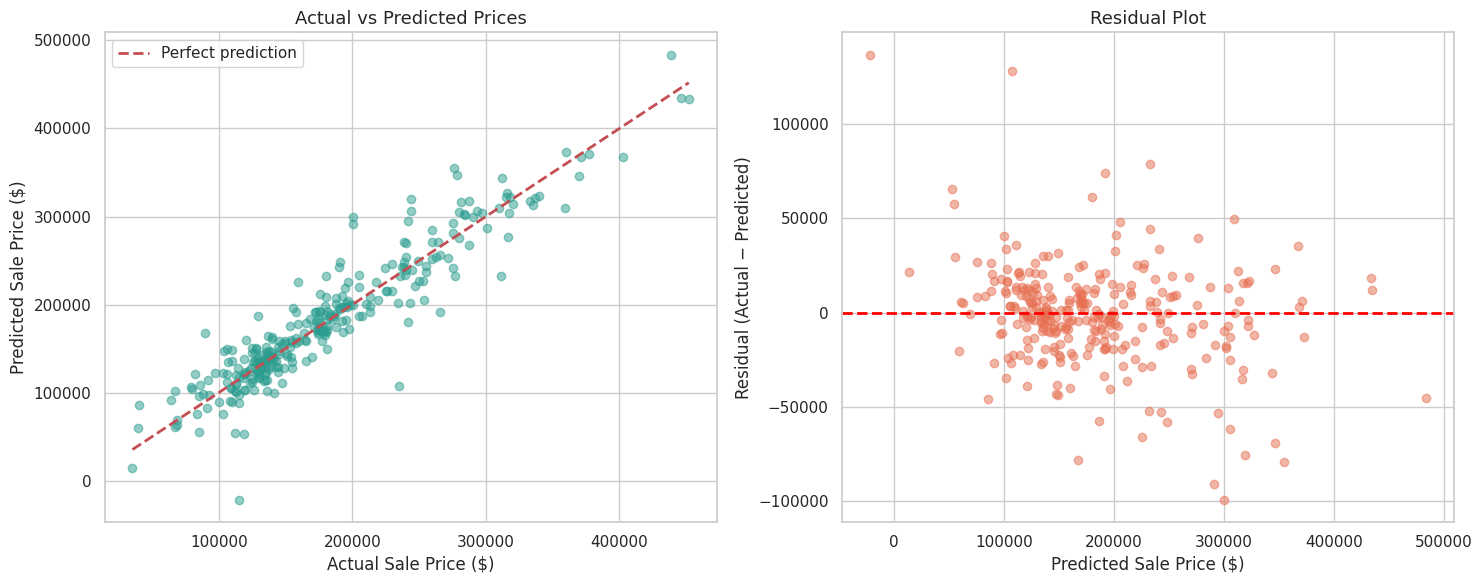

In [40]:
# Residuals = the leftover errors = actual price - predicted price
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- PLOT 1: Actual vs Predicted ---
# Each dot is a house. The red dashed line is "perfect prediction" (predicted == actual).
# The closer the dots hug that line, the better.
axes[0].scatter(y_test, y_pred, alpha=0.5, color="#2a9d8f")
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual Sale Price ($)")
axes[0].set_ylabel("Predicted Sale Price ($)")
axes[0].set_title("Actual vs Predicted Prices")
axes[0].legend()

# --- PLOT 2: Residual plot ---
# Errors vs predicted price. We WANT a shapeless cloud centred on the red line at 0,
# meaning errors are random. A pattern (curve/funnel) would reveal a problem.
axes[1].scatter(y_pred, residuals, alpha=0.5, color="#e76f51")
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Predicted Sale Price ($)")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

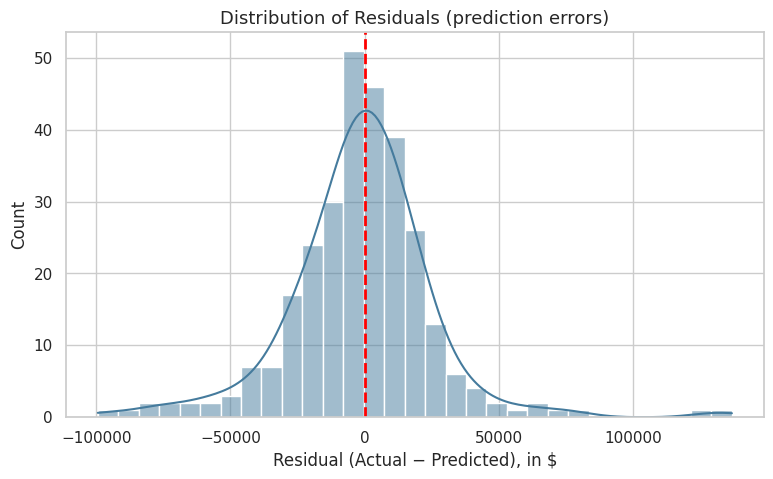

In [41]:
# It also helps to see the distribution of the errors themselves.
plt.figure(figsize=(9, 5))
sns.histplot(residuals, kde=True, color="#457b9d")
plt.axvline(x=0, color="red", linestyle="--", linewidth=2)
plt.title("Distribution of Residuals (prediction errors)")
plt.xlabel("Residual (Actual − Predicted), in $")
plt.show()

## 🔎 Output Explanation

- **Actual vs Predicted:** dots cluster tightly around the red "perfect" diagonal, which means
  predictions are generally close to reality. The model tends to be **less accurate for the most
  expensive homes** (top-right dots stray further) — partly the skew and the outliers we found in
  EDA.
- **Residual plot:** the errors form a roughly shapeless cloud centred on zero — good news,
  meaning the model isn't systematically biased. Any clear curve or funnel shape would have hinted
  that a straight-line model is missing something (e.g. that we should model `log(SalePrice)`).
- **Residual distribution:** roughly bell-shaped and centred on \$0, telling us errors are
  mostly small and balanced between over- and under-prediction, with a few larger misses in the
  tails.

> **✅ Key Points**  
> • Always evaluate on the **unseen test set**, never the training set.  
> • **MAE/RMSE** are errors in **dollars** (lower = better); **R²/Adjusted R²** are explained variation (higher = better).  
> • **RMSE ≥ MAE** because RMSE punishes big errors more.  
> • **Plots** reveal the *shape* of errors that single numbers hide; residuals should look like a random cloud around 0.

> **⚠️ Common Mistakes**  
> • Reporting accuracy on the **training** data (misleadingly high).  
> • Using **R²** for a classification problem (it's a regression metric).  
> • Looking only at one metric — check several **and** the plots together.  
> • Ignoring a clear **pattern** in the residual plot, which is the model telling you it's missing something.


---
# 🎁 Bonus / Next Steps (Optional)

You now have a **complete, working** regression project. Everything above is the core syllabus.
This optional section shows two natural next steps: a quick **improvement**, and how to make a
real **Kaggle submission**.

## A. One easy improvement: predict `log(SalePrice)`

Back in EDA we saw `SalePrice` is **right-skewed**, and linear models prefer a symmetric target.
The classic fix is to train on `log(SalePrice)` and convert the prediction back afterwards. Let's
measure whether it actually helps — using the *same* pipeline, changing **only** the target.


In [42]:
# Train an identical pipeline, but on the LOG of the price.
# np.log1p(x) = log(1 + x); np.expm1(x) is its exact inverse to get dollars back.
model_log = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])
model_log.fit(X_train, np.log1p(y_train))            # learn on log-prices

# Predict, then convert predictions from log-space back to dollars
y_pred_log = np.expm1(model_log.predict(X_test))

# Compare RMSE in dollars: original model vs log-target model
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(f"RMSE — original (raw price)  : ${rmse:,.0f}")
print(f"RMSE — log-target model      : ${rmse_log:,.0f}")
improvement = (rmse - rmse_log) / rmse * 100
print(f"Improvement                  : {improvement:.1f}% lower error")

RMSE — original (raw price)  : $26,969
RMSE — log-target model      : $21,709
Improvement                  : 19.5% lower error


**🔎 Output Explanation.** Simply predicting the **log** of the price — with no other
change — usually **reduces the error noticeably**, because it tames the skew and the influence of
very expensive homes. This is a perfect illustration of the workflow's feedback loop: an insight
from **EDA** (skew) led directly to a **better model**.

**Where to go next (in rough order of payoff):**
- Try **regularised** linear models — **Ridge** and **Lasso** — which handle many one-hot
  columns and multicollinearity more gracefully than plain linear regression.
- Try **tree-based** models like **RandomForestRegressor** or **GradientBoosting/XGBoost**, which
  capture curves and interactions automatically (and need no scaling).
- Use **cross-validation** (e.g. `cross_val_score`) for a more reliable score than a single split.
- Do more **feature engineering** (e.g. encode quality words `Ex/Gd/TA/Fa/Po` as ordered numbers).


**🔎 Output Explanation.** We produced one predicted price per test house in the precise
`Id, SalePrice` layout Kaggle wants (compare it to `sample_submission.csv`). Uploading this file
to the competition page would give you a public leaderboard score. Notice the discipline: the
test data went through the **identical** cleaning, feature engineering, and pipeline as the
training data — which is exactly why wrapping everything in functions and a `Pipeline` matters.

---

